In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
import scipy
from scipy.stats import poisson
import math
from scipy.linalg import expm
import scipy.optimize as opt
import os
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

from scripts.util.util import apply_ll_large, combine_results_immune
plt.rcParams["font.family"] = "Arial"

N = 59394

In [2]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams['font.size'] = 7
plt.rcParams['svg.fonttype'] = 'none'
labelfont = {'fontname':'Arial', "fontsize":8}
legendfont = 8
cm = 1/2.54  # centimeters in inches
x_size = 18*cm
y_size = 27.6*cm

In [3]:
current_working_directory = os.getcwd()
path_to_plots = current_working_directory+"/figs/"
path_to_parameters = current_working_directory+"/parameters/"
path_to_results = current_working_directory+"/results/"
path_to_data = current_working_directory+"/data/"

# Build parameter file

In [4]:
diseases_parameters = pd.read_csv(path_to_parameters+"model/run1/diseases_parameters.csv")
diseases_parameters["second_dose"] = 7745

diseases_parameters.to_csv(path_to_parameters+"immune/immune/diseases_parameters.csv", index=False)

LL_berlin = -53.249451796807584


In [5]:
multiple = 3
repo = path_to_results+"model/run3"
LL_range_D, LL_range_I, LL_range_lambda, LL_range_R, LL_range_R_lambda, LL_range_M, LL_range_mean_degree_I, LL_range_I_degrees = apply_ll_large(repo, multiple, LL_berlin)

del LL_range_I, LL_range_lambda, LL_range_R_lambda, LL_range_M, LL_range_mean_degree_I, LL_range_I_degrees

100000
100000
100000
100000
100000
100000
100000
100000
100000
100000
143


In [6]:
parameter_main = LL_range_D[["inf_prob", "diag_prob", "i0", "behaviour_change", "behaviour_change_rate"]].reset_index()
parameter_main["index"] = LL_range_D.index
print(parameter_main)

      index  inf_prob  diag_prob    i0  behaviour_change  \
0      1921  0.668394   0.295181  15.0          0.098161   
1      2050  0.691437   0.234859  10.0          0.096773   
2     10094  0.676844   0.246537  19.0          0.592668   
3     14430  0.688814   0.239263  16.0          0.204087   
4     18965  0.697398   0.236342  11.0          0.108988   
..      ...       ...        ...   ...               ...   
138  482164  0.684697   0.237975  17.0          0.211941   
139  487827  0.671784   0.237835   9.0          0.295895   
140  492902  0.667922   0.263730  19.0          0.301781   
141  493817  0.679786   0.249475  15.0          0.093369   
142  495430  0.670064   0.266303  17.0          0.305178   

     behaviour_change_rate  
0                 0.009623  
1                 0.092011  
2                 0.125776  
3                 0.040114  
4                 0.095521  
..                     ...  
138               0.048997  
139               0.009791  
140               

In [7]:
# VE efficacy data: https://www.sciencedirect.com/science/article/pii/S0264410X24006947
vaccine_effincacy1_all = list(np.linspace(64,88, 88-64+1))
vaccine_efficacy2_all = list(np.linspace(72,92, 92-72+1))

efficacies_all = []
for vac1 in vaccine_effincacy1_all:
    for vac2 in vaccine_efficacy2_all:
        for inf in range(int(vac2), 100):
            if (vac1 <= vac2) and (vac2 <= inf):
                efficacies_all.append([vac1/100, vac2/100, inf/100])


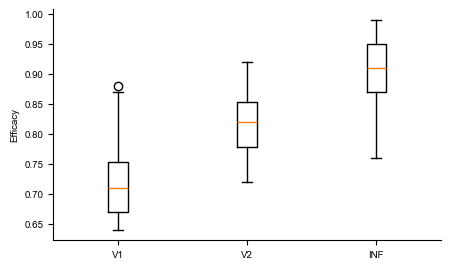

In [8]:
fig, ax = plt.subplots(1,1,figsize = [5,3])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

np.random.seed(7)
indices = np.random.choice(len(efficacies_all), 100, replace=False)
efficacies_all_reduced = []
vac1 = []
vac2 = []
inf = []
for index in indices:
    efficacies_all_reduced.append(efficacies_all[index])
    vac1.append(efficacies_all[index][0])
    vac2.append(efficacies_all[index][1])
    inf.append(efficacies_all[index][2])

ax.boxplot(vac1, positions=[0])
ax.boxplot(vac2, positions=[1])
ax.boxplot(inf, positions=[2])
ax.set_ylabel("Efficacy")

plt.xticks([0,1,2],["V1", "V2", "INF"])
plt.savefig(path_to_plots+"/efficacies.pdf", bbox_inches='tight')
plt.show()



In [9]:
# Caution: takes several minutes 
sampled_parameters = pd.DataFrame(columns=["index","inf_prob", "diag_prob", "i0", "behaviour_change", "behaviour_change_rate", "first_outbreak_size", "vaccine_efficacy1", "vaccine_efficacy2", "infection_efficacy"])

k = 0
for i in range(len(parameter_main)):
    first_outbreak_size = LL_range_R.iloc[i]["25"]
    for l in range(len(efficacies_all_reduced)):
        for s in range(10):
            sampled_parameters.loc[k] = list(parameter_main.iloc[i]) + [first_outbreak_size] + efficacies_all_reduced[l]
            k +=1

sampled_parameters.to_csv(path_to_parameters+"immune/immune/sampled_parameters.csv", index=False)
print(sampled_parameters.head())
print(len(sampled_parameters))

    index  inf_prob  diag_prob    i0  behaviour_change  behaviour_change_rate  \
0  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
1  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
2  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
3  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
4  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   

   first_outbreak_size  vaccine_efficacy1  vaccine_efficacy2  \
0               6825.0               0.72               0.84   
1               6825.0               0.72               0.84   
2               6825.0               0.72               0.84   
3               6825.0               0.72               0.84   
4               6825.0               0.72               0.84   

   infection_efficacy  
0                 0.9  
1                 0.9  
2                 0.9  
3                 0.9  
4       

In [10]:
sampled_parameters_vacc = sampled_parameters.copy()
sampled_parameters_vacc["infection_efficacy"] = 0
sampled_parameters_vacc.to_csv(path_to_parameters+"immune/only_vacc/sampled_parameters.csv", index=False)
print(sampled_parameters_vacc.head())
print(len(sampled_parameters_vacc))
del sampled_parameters_vacc

    index  inf_prob  diag_prob    i0  behaviour_change  behaviour_change_rate  \
0  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
1  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
2  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
3  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
4  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   

   first_outbreak_size  vaccine_efficacy1  vaccine_efficacy2  \
0               6825.0               0.72               0.84   
1               6825.0               0.72               0.84   
2               6825.0               0.72               0.84   
3               6825.0               0.72               0.84   
4               6825.0               0.72               0.84   

   infection_efficacy  
0                   0  
1                   0  
2                   0  
3                   0  
4       

In [11]:
sampled_parameters_novacc = sampled_parameters.copy()
sampled_parameters_novacc["vaccine_efficacy1"] = 0
sampled_parameters_novacc["vaccine_efficacy2"] = 0
sampled_parameters_novacc.to_csv(path_to_parameters+"immune/only_infection/sampled_parameters.csv", index=False)
print(sampled_parameters_novacc.head())
print(len(sampled_parameters_novacc))
del sampled_parameters_novacc

    index  inf_prob  diag_prob    i0  behaviour_change  behaviour_change_rate  \
0  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
1  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
2  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
3  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
4  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   

   first_outbreak_size  vaccine_efficacy1  vaccine_efficacy2  \
0               6825.0                  0                  0   
1               6825.0                  0                  0   
2               6825.0                  0                  0   
3               6825.0                  0                  0   
4               6825.0                  0                  0   

   infection_efficacy  
0                 0.9  
1                 0.9  
2                 0.9  
3                 0.9  
4       

In [12]:
sampled_parameters_replacement = sampled_parameters.copy()
sampled_parameters_replacement["replacement_percentage"] = [x/100 for x in range(1,11)] * 143 * 100
sampled_parameters_replacement.to_csv(path_to_parameters+"immune/replacement/sampled_parameters.csv", index=False)
print(sampled_parameters_replacement.head())
print(len(sampled_parameters_replacement))
del sampled_parameters_replacement

    index  inf_prob  diag_prob    i0  behaviour_change  behaviour_change_rate  \
0  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
1  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
2  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
3  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
4  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   

   first_outbreak_size  vaccine_efficacy1  vaccine_efficacy2  \
0               6825.0               0.72               0.84   
1               6825.0               0.72               0.84   
2               6825.0               0.72               0.84   
3               6825.0               0.72               0.84   
4               6825.0               0.72               0.84   

   infection_efficacy  replacement_percentage  
0                 0.9                    0.01  
1                 0.9           

In [13]:
sampled_parameters_replacement = sampled_parameters.copy()
sampled_parameters_replacement["replacement_percentage"] = [x/10 for x in range(1,11)] * 143 * 100
sampled_parameters_replacement.to_csv(path_to_parameters+"immune/replacement2/sampled_parameters.csv", index=False)
print(sampled_parameters_replacement.head())
print(len(sampled_parameters_replacement))
del sampled_parameters_replacement

    index  inf_prob  diag_prob    i0  behaviour_change  behaviour_change_rate  \
0  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
1  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
2  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
3  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
4  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   

   first_outbreak_size  vaccine_efficacy1  vaccine_efficacy2  \
0               6825.0               0.72               0.84   
1               6825.0               0.72               0.84   
2               6825.0               0.72               0.84   
3               6825.0               0.72               0.84   
4               6825.0               0.72               0.84   

   infection_efficacy  replacement_percentage  
0                 0.9                     0.1  
1                 0.9           

In [14]:
sampled_parameters_permutation = sampled_parameters.copy()
sampled_parameters_permutation["replacement_percentage"] = 0
sampled_parameters_permutation["permutation_percentage"] = [x/10 for x in range(1,11)] * 143 * 100
sampled_parameters_permutation.to_csv(path_to_parameters+"immune/permutation/sampled_parameters.csv", index=False)
print(sampled_parameters_permutation.head())
print(len(sampled_parameters_permutation))
del sampled_parameters_permutation

    index  inf_prob  diag_prob    i0  behaviour_change  behaviour_change_rate  \
0  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
1  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
2  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
3  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   
4  1921.0  0.668394   0.295181  15.0          0.098161               0.009623   

   first_outbreak_size  vaccine_efficacy1  vaccine_efficacy2  \
0               6825.0               0.72               0.84   
1               6825.0               0.72               0.84   
2               6825.0               0.72               0.84   
3               6825.0               0.72               0.84   
4               6825.0               0.72               0.84   

   infection_efficacy  replacement_percentage  permutation_percentage  
0                 0.9                       0           

# Results

In [15]:
# import first run
# all runs, no matter the LL
multiple = np.inf
repo = path_to_results+"model/run3"
LL_range_D, LL_range_I, LL_range_lambda, data_R_first, LL_range_R_lambda, LL_range_M, LL_range_mean_degree_I, LL_range_I_degrees = apply_ll_large(repo, multiple, LL_berlin)

del LL_range_D, LL_range_I, LL_range_lambda, LL_range_R_lambda, LL_range_M, LL_range_mean_degree_I, LL_range_I_degrees

data_R_first["outbreak_size_adjusted"] = data_R_first["25"] - data_R_first["i0"]
data_R_first["outbreak_size_relative"] = data_R_first["outbreak_size_adjusted"]/N*100

100000
100000
100000
100000
100000
100000
100000
100000
100000
100000
500000


In [16]:
# get results for second wave
repo = path_to_results+"immune/"
data_D_second, data_I_second, data_R0_second = combine_results_immune(repo+"immune", 1430)
data_D_second_vacc, data_I_second_vacc, data_R0_second_vacc = combine_results_immune(repo+"only_vacc", 1430)
data_D_second_novacc, data_I_second_novacc, data_R0_second_novacc = combine_results_immune(repo+"only_infection", 1430)
data_D_second_replacement, data_I_second_replacement, data_R0_second_replacement = combine_results_immune(repo+"replacement", 1430)
data_D_second_replacement2, data_I_second_replacement2, data_R0_second_replacement2 = combine_results_immune(repo+"replacement2", 1430)
data_D_second_replacement_nobc, data_I_second_replacement_nobc, data_R0_second_replacement_nobc = combine_results_immune(repo+"replacement_nobc", 1430)
data_D_second_replacement2_nobc, data_I_second_replacement2_nobc, data_R0_second_replacement2_nobc = combine_results_immune(repo+"replacement2_nobc", 1430)
data_D_second_permutation, data_I_second_permutation, data_R0_second_permutation = combine_results_immune(repo+"permutation", 1430)

In [17]:
N = 59394
# get relative outbreak sizes
data_I_second["second_outbreak_size"] = np.sum(data_I_second.iloc[:,7:33], axis = 1)
data_I_second["second_outbreak_size_adjusted"] = data_I_second["second_outbreak_size"] - data_I_second["i0"]
data_I_second["second_outbreak_size_relative"] = data_I_second["second_outbreak_size_adjusted"]/N*100

data_I_second_vacc["second_outbreak_size"] = np.sum(data_I_second_vacc.iloc[:,7:33], axis = 1)
data_I_second_vacc["second_outbreak_size_adjusted"] = data_I_second_vacc["second_outbreak_size"] - data_I_second_vacc["i0"]
data_I_second_vacc["second_outbreak_size_relative"] = data_I_second_vacc["second_outbreak_size_adjusted"]/N*100

data_I_second_novacc["second_outbreak_size"] = np.sum(data_I_second_novacc.iloc[:,7:33], axis = 1)
data_I_second_novacc["second_outbreak_size_adjusted"] = data_I_second_novacc["second_outbreak_size"] - data_I_second_novacc["i0"]
data_I_second_novacc["second_outbreak_size_relative"] = data_I_second_novacc["second_outbreak_size_adjusted"]/N*100

data_I_second_replacement = pd.concat([data_I_second_replacement, data_I_second_replacement2])
data_I_second_replacement["second_outbreak_size"] = np.sum(data_I_second_replacement.iloc[:,7:33], axis = 1)
data_I_second_replacement["second_outbreak_size_adjusted"] = data_I_second_replacement["second_outbreak_size"] - data_I_second_replacement["i0"]
data_I_second_replacement["second_outbreak_size_relative"] = data_I_second_replacement["second_outbreak_size_adjusted"]/N*100

data_I_second_replacement_nobc = pd.concat([data_I_second_replacement_nobc, data_I_second_replacement2_nobc])
data_I_second_replacement_nobc["second_outbreak_size"] = np.sum(data_I_second_replacement_nobc.iloc[:,7:33], axis = 1)
data_I_second_replacement_nobc["second_outbreak_size_adjusted"] = data_I_second_replacement_nobc["second_outbreak_size"] - data_I_second_replacement_nobc["i0"]
data_I_second_replacement_nobc["second_outbreak_size_relative"] = data_I_second_replacement_nobc["second_outbreak_size_adjusted"]/N*100

data_I_second_permutation["second_outbreak_size"] = np.sum(data_I_second_permutation.iloc[:,7:33], axis = 1)
data_I_second_permutation["second_outbreak_size_adjusted"] = data_I_second_permutation["second_outbreak_size"] - data_I_second_permutation["i0"]
data_I_second_permutation["second_outbreak_size_relative"] = data_I_second_permutation["second_outbreak_size_adjusted"]/N*100


Vaccination
3.712395262077048
0.02525507627033034
5.241270161969223
Infection
0.06269895878442197
0.0050510152540660675
0.22729568643297302
Both
0.019724532463192935
0.0016836717513553556
0.06229585480014816
0.32158130450887296
37.31560209424084


/Users/nilsgubela/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3502: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/Users/nilsgubela/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3502: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/Users/nilsgubela/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3502: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=

1.2783442607162174
0.018520389264908843
2.6543506078055015


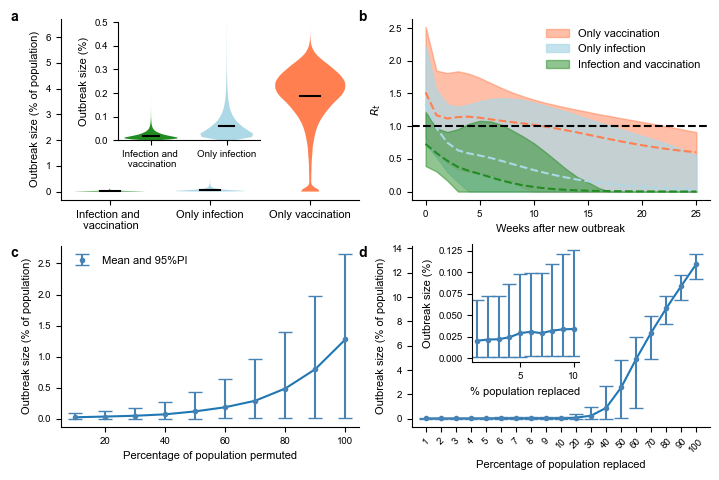

In [23]:
# Figure 5

fig = plt.figure(figsize=(x_size, x_size/1.5))
col = "second_outbreak_size_relative"


# upper left panel
# outbreak size distribution
size = 10
ax = fig.add_subplot(2,2,1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# inset figure 
left, bottom, width, height = [0.15, 0.72, 0.2, 0.25]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# only vaccination
color = "coral"
label = "Only vaccination"
violin_parts = ax.violinplot(data_I_second_vacc[col], [2], points=80, widths=0.7,showmeans=False,showmedians=False,showextrema=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor(color)
    pc.set_alpha(1)
ax.plot([1.9, 2.1], np.ones(2)*np.mean(data_I_second_vacc[col]),color = "black")

print("Vaccination")
print(np.mean(data_I_second_vacc[col]))
print(np.quantile(data_I_second_vacc[col], 0.025))
print(np.quantile(data_I_second_vacc[col], 0.975))
#print("Zero secondary cases: "+ str(counts[0]/np.sum(counts)))


# only infection
#color = "steelblue"
color = "lightblue"
label = "Only infection"
print("Infection")
print(np.mean(data_I_second_novacc[col]))
print(np.quantile(data_I_second_novacc[col], 0.025))
print(np.quantile(data_I_second_novacc[col], 0.975))
#print("Zero secondary cases: "+ str(counts[0]/np.sum(counts)))

violin_parts = ax.violinplot(data_I_second_novacc[col], [1], points=80, widths=0.7,showmeans=False,showmedians=False,showextrema=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor(color)
    pc.set_alpha(1)
ax.plot([0.9, 1.1], np.ones(2)*np.mean(data_I_second_novacc[col]),color = "black")

violin_parts = ax2.violinplot(data_I_second_novacc[col], [1], points=80, widths=0.7,showmeans=False,showmedians=False,showextrema=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor(color)
    pc.set_alpha(1)
ax2.plot([0.9, 1.1], np.ones(2)*np.mean(data_I_second_novacc[col]),color = "black")

# infection + vacc
color = "forestgreen"
print("Both")
print(np.mean(data_I_second[col]))
print(np.quantile(data_I_second[col], 0.025))
print(np.quantile(data_I_second[col], 0.975))
print(np.max(data_I_second[col]))
#print("Zero secondary cases: "+ str(counts[0]/np.sum(counts)))
print(12/np.max(data_I_second[col]))

violin_parts = ax.violinplot(data_I_second[col], [0], points=80, widths=0.7,showmeans=False,showmedians=False,showextrema=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor(color)
    pc.set_alpha(1)
ax.plot([-0.1, 0.1], np.ones(2)*np.mean(data_I_second[col]),color = "black")

violin_parts = ax2.violinplot(data_I_second[col], [0], points=80, widths=0.7,showmeans=False,showmedians=False,showextrema=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor(color)
    pc.set_alpha(1)
ax2.plot([-0.1, 0.1], np.ones(2)*np.mean(data_I_second[col]),color = "black")


ax.set_ylabel("Outbreak size (% of population)", **labelfont)
ax.set_xticks([0,1,2])
ax.set_xticklabels(["Infection and \n vaccination", "Only infection", "Only vaccination"],**labelfont)

ax2.set_ylabel("Outbreak size (%)", **labelfont)
ax2.set_xticks([0,1])
ax2.set_xticklabels(["Infection and \n vaccination", "Only infection"])
ax2.set_ylim(0,0.5)

# save data
fig5a_df = pd.DataFrame({'number simulation': np.arange(len(data_I_second_vacc[col])), 'only vaccination': data_I_second_vacc[col], 'only infection':data_I_second_novacc[col], 'infection + vaccination': data_I_second[col]})
fig5a_df.to_csv('results/plot_data/fig5a_df.csv', index=False)

# upper right panel
# R0 timelines
ax = fig.add_subplot(2,2,2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

t = np.linspace(0,25,26)
ax.plot(t,np.mean(data_R0_second_vacc.iloc[:,7:33]), color = "coral", linestyle = "dashed")
ax.fill_between(t,data_R0_second_vacc.iloc[:,7:33].quantile(0.025), data_R0_second_vacc.iloc[:,7:33].quantile(0.975), color = "coral", alpha = 0.5, label = "Only vaccination")

ax.plot(t,np.mean(data_R0_second_novacc.iloc[:,7:33]), color = "lightblue", linestyle = "dashed")
ax.fill_between(t,data_R0_second_novacc.iloc[:,7:33].quantile(0.025), data_R0_second_novacc.iloc[:,7:33].quantile(0.975), color = "lightblue", alpha = 0.7, label = "Only infection")

ax.plot(t,np.mean(data_R0_second.iloc[:,7:33]), color = "forestgreen", linestyle = "dashed")
ax.fill_between(t,data_R0_second.iloc[:,7:33].quantile(0.025), data_R0_second.iloc[:,7:33].quantile(0.975), color = "forestgreen", alpha = 0.5, label = "Infection and vaccination")


ax.set_xlabel("Weeks after new outbreak", **labelfont)
ax.set_ylabel(r"$R_t$", **labelfont)
ax.axhline(y=1, color = "black", linestyle = "dashed")

ax.legend(frameon=False,prop={'size': legendfont})

df1 = pd.DataFrame({'t': t, 'Only vaccination mean': np.mean(data_R0_second_vacc.iloc[:,7:33]), "Only vaccination Q0.025": data_R0_second_vacc.iloc[:,7:33].quantile(0.025), "Only vaccination Q0.975": data_R0_second_vacc.iloc[:,7:33].quantile(0.975)})
df2 = pd.DataFrame({'t': t, 'Only infection mean': np.mean(data_R0_second_novacc.iloc[:,7:33]), "Only infection Q0.025": data_R0_second_novacc.iloc[:,7:33].quantile(0.025), "Only infection Q0.975": data_R0_second_novacc.iloc[:,7:33].quantile(0.975)})
df3 = pd.DataFrame({'t': t, 'Infection and vaccination mean': np.mean(data_R0_second.iloc[:,7:33]), "Infection and vaccination Q0.025": data_R0_second.iloc[:,7:33].quantile(0.025), "Infection and vaccination Q0.975": data_R0_second.iloc[:,7:33].quantile(0.975)})

merged_df = pd.merge(df1, df2, on='t', how='outer')
fig5b_df = pd.merge(merged_df, df3, on='t', how='outer')
fig5b_df.sort_values(by='t', inplace=True)
fig5b_df.to_csv('results/plot_data/fig5b_df.csv', index=False)


# lower left
# permutation
ax = fig.add_subplot(2,2,3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

col = "second_outbreak_size_relative"

# data aggregation 
df = data_I_second_permutation.groupby(['permutation_percentage'], as_index=False)[col].mean()
df_lower = data_I_second_permutation.groupby(['permutation_percentage'], as_index=False)[col].quantile(0.025)
df_upper = data_I_second_permutation.groupby(['permutation_percentage'], as_index=False)[col].quantile(0.975)

y_upper = df_upper[col].values - df[col].values
y_lower = df[col].values - df_lower[col].values
c = [y_lower, y_upper]
t = [x*10 for x in range(1,11)]

ax.plot(t, df[col])
ax.errorbar(t, df[col], yerr=c, fmt='.k', color="steelblue",  capsize=5, capthick=1, label = "Mean and 95%PI")
ax.legend(frameon=False,prop={'size': legendfont})

ax.set_xlabel("Percentage of population permuted", **labelfont)
ax.set_ylabel("Outbreak size (% of population)",**labelfont)
print(df[col].values[-1])
print(df[col].values[-1] - y_lower[-1])
print(df[col].values[-1] + y_upper[-1])

fig5c_df = pd.DataFrame({'percentage population': t, 'mean': df[col], "Q0.025": df_lower[col].values, "SP Q0.975": df_upper[col].values})
fig5c_df.to_csv('results/plot_data/fig5c_df.csv', index=False)

# lower right
# replacement
ax = fig.add_subplot(2,2,4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# data aggregation 
col = "second_outbreak_size_relative"
df = data_I_second_replacement.groupby(['replacement_percentage'], as_index=False)[col].mean()
df_lower = data_I_second_replacement.groupby(['replacement_percentage'], as_index=False)[col].quantile(0.025)
df_upper = data_I_second_replacement.groupby(['replacement_percentage'], as_index=False)[col].quantile(0.975)

y_upper = df_upper[col].values - df[col].values
y_lower = df[col].values - df_lower[col].values
c = [y_lower, y_upper]
t = list(range(1,20))

ax.plot(t, df[col])
ax.errorbar(t, df[col], yerr=c, fmt='.k', color="steelblue",  capsize=5, capthick=1)

ax.set_xticks(t)
ax.set_xticklabels(np.array(df["replacement_percentage"].values*100, dtype=int), rotation=45)

ax.set_xlabel("Percentage of population replaced", **labelfont)
ax.set_ylabel("Outbreak size (% of population)",**labelfont)

# inset figure 
left, bottom, width, height = [0.65, 0.25, 0.15, 0.25]
ax2 = fig.add_axes([left, bottom, width, height])

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# plot first half of plot
c1 = [y_lower[:10], y_upper[:10]]
ax2.plot(t[:10], df[col][:10])
ax2.errorbar(t[:10], df[col][:10], yerr=c1, fmt='.k', color="steelblue",  capsize=5, capthick=1)
ax2.set_xlabel("% population replaced", **labelfont)
ax2.set_ylabel("Outbreak size (%)",**labelfont)


fig5d_df = pd.DataFrame({'percentage population': t, 'mean': df[col], "Q0.025": df_lower[col].values, "SP Q0.975": df_upper[col].values})
fig5d_df.to_csv('results/plot_data/fig5d_df.csv', index=False)


fig.tight_layout()

ax.text(-1.35,2.3,
           'a',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


ax.text(-0.18,2.3,
           'b',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


ax.text(-1.35,1,
           'c',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


ax.text(-0.18,1,
           'd',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


plt.savefig(path_to_plots+"/figure5.pdf", bbox_inches='tight')
plt.savefig(path_to_plots+"/figure5.svg", bbox_inches='tight')


## Unused figures

/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_28417/2305388128.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(t, df[col], yerr=c, fmt='.k', color="steelblue",  capsize=5, capthick=1)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_28417/2305388128.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(t, df[col], yerr=c, fmt='.k', color="coral",  capsize=5, capthick=1)


Text(0, 0.5, 'Outbreak size as share of population')

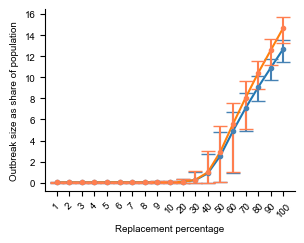

In [438]:
fig = plt.figure(figsize=(x_size, x_size/3))

ax = fig.add_subplot(1,2,1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

col = "second_outbreak_size_relative"

#data_I_second_replacement["replacement"] = [x/100 for x in range(1,11)] * 143*100

# data aggregation with bc
df = data_I_second_replacement.groupby(['replacement_percentage'], as_index=False)[col].mean()
df_lower = data_I_second_replacement.groupby(['replacement_percentage'], as_index=False)[col].quantile(0.025)
df_upper = data_I_second_replacement.groupby(['replacement_percentage'], as_index=False)[col].quantile(0.975)

y_upper = df_upper[col].values - df[col].values
y_lower = df[col].values - df_lower[col].values

c = [y_lower, y_upper]

t = list(range(1,20))

ax.plot(t, df[col])
#plt.fill_between(t, df_upper[col].values, df_lower[col].values, alpha = 0.1)
ax.errorbar(t, df[col], yerr=c, fmt='.k', color="steelblue",  capsize=5, capthick=1)

# data aggregation without bc
df = data_I_second_replacement_nobc.groupby(['replacement_percentage'], as_index=False)[col].mean()
df_lower = data_I_second_replacement_nobc.groupby(['replacement_percentage'], as_index=False)[col].quantile(0.025)
df_upper = data_I_second_replacement_nobc.groupby(['replacement_percentage'], as_index=False)[col].quantile(0.975)

y_upper = df_upper[col].values - df[col].values
y_lower = df[col].values - df_lower[col].values

c = [y_lower, y_upper]

#t = list(range(0,10))

ax.plot(t, df[col])
#plt.fill_between(t, df_upper[col].values, df_lower[col].values, alpha = 0.1)
ax.errorbar(t, df[col], yerr=c, fmt='.k', color="coral",  capsize=5, capthick=1)


ax.set_xticks(t)
ax.set_xticklabels(np.array(df["replacement_percentage"].values*100, dtype=int), rotation=45)

ax.set_xlabel("Replacement percentage")
ax.set_ylabel("Outbreak size as share of population")


# inset figure 
#left, bottom, width, height = [0.15, 0.3, 0.2, 0.4]
#ax2 = fig.add_axes([left, bottom, width, height])

#ax2.spines['top'].set_visible(False)
#ax2.spines['right'].set_visible(False)

# plot first half of plot
#c1 = [y_lower[:10], y_upper[:10]]
#ax2.plot(t[:10], df[col][:10])
#plt.fill_between(t, df_upper[col].values, df_lower[col].values, alpha = 0.1)
#ax2.errorbar(t[:10], df[col][:10], yerr=c1, fmt='.k', color="steelblue",  capsize=5, capthick=1)

#ax.set_yscale("log",base=10)


Permutation both:
1.3142022775016007
0.0151530457621982
2.6938748021685694
4.402801629794255
Zero secondary cases: 0.05367832167832168
2.7255372848948376


'\n# permutation infection\ncolor = "steelblue"\nlabel = "Only infection"\nvalues, counts = np.unique(np.round(data_I_second_permutation_novacc[col], 1), return_counts=True)\n#ax.bar(values, counts/len(data_I_second_novacc[col]), width = 0.1, color = color, label = label)\nplt.scatter(values, counts/len(data_I_second_permutation_novacc[col]), color = color, label = label, s=size)\nplt.plot(values, counts/len(data_I_second_permutation_novacc[col]), color = color)\nprint("Permutation infection")\nprint(np.mean(data_I_second_permutation_novacc[col]))\nprint(np.quantile(data_I_second_permutation_novacc[col], 0.025))\nprint(np.quantile(data_I_second_permutation_novacc[col], 0.975))\nprint("Zero secondary cases: "+ str(counts[0]/np.sum(counts)))\n'

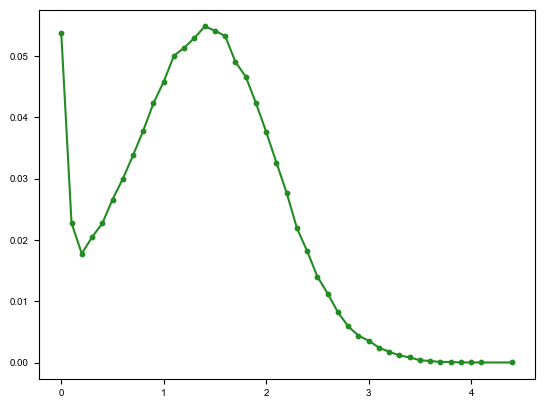

In [354]:
# permutation both
color = "forestgreen"
values, counts = np.unique(np.round(data_I_second_permutation[col], 1), return_counts=True)
plt.scatter(values, counts/len(data_I_second_permutation[col]), color = color, label = "Infection and Vaccination", s = size)
plt.plot(values, counts/len(data_I_second_permutation[col]), color = color)
print("Permutation both:")
print(np.mean(data_I_second_permutation[col]))
print(np.quantile(data_I_second_permutation[col], 0.025))
print(np.quantile(data_I_second_permutation[col], 0.975))
print(np.max(data_I_second_permutation[col]))
print("Zero secondary cases: "+ str(counts[0]/np.sum(counts)))

'''
# permutation infection
color = "steelblue"
label = "Only infection"
values, counts = np.unique(np.round(data_I_second_permutation_novacc[col], 1), return_counts=True)
#ax.bar(values, counts/len(data_I_second_novacc[col]), width = 0.1, color = color, label = label)
plt.scatter(values, counts/len(data_I_second_permutation_novacc[col]), color = color, label = label, s=size)
plt.plot(values, counts/len(data_I_second_permutation_novacc[col]), color = color)
print("Permutation infection")
print(np.mean(data_I_second_permutation_novacc[col]))
print(np.quantile(data_I_second_permutation_novacc[col], 0.025))
print(np.quantile(data_I_second_permutation_novacc[col], 0.975))
print("Zero secondary cases: "+ str(counts[0]/np.sum(counts)))
'''

/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_28417/1492569071.py:24: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(t, df[col], yerr=c, fmt='.k', color="steelblue",  capsize=5, capthick=1)


Text(0, 0.5, 'Outbreak size as share of population')

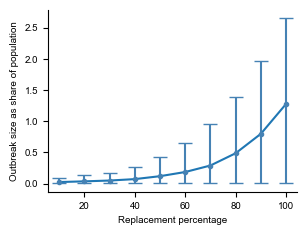

In [386]:
fig = plt.figure(figsize=(x_size, x_size/3))

ax = fig.add_subplot(1,2,1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

col = "second_outbreak_size_relative"

# data aggregation 
#data_I_second_permutation['permutation_percentage'] = [x/10 for x in range(1,11)] * 143 * 100
df = data_I_second_permutation.groupby(['permutation_percentage'], as_index=False)[col].mean()
df_lower = data_I_second_permutation.groupby(['permutation_percentage'], as_index=False)[col].quantile(0.025)
df_upper = data_I_second_permutation.groupby(['permutation_percentage'], as_index=False)[col].quantile(0.975)

y_upper = df_upper[col].values - df[col].values
y_lower = df[col].values - df_lower[col].values

c = [y_lower, y_upper]

t = [x*10 for x in range(1,11)]

ax.plot(t, df[col])
#plt.fill_between(t, df_upper[col].values, df_lower[col].values, alpha = 0.1)
ax.errorbar(t, df[col], yerr=c, fmt='.k', color="steelblue",  capsize=5, capthick=1)


#ax.set_xticks(t)
#ax.set_xticklabels(np.array(df["replacement_percentage"].values*100, dtype=int), rotation=45)

ax.set_xlabel("Replacement percentage")
ax.set_ylabel("Outbreak size as share of population")
